# F_photometry_examples.ipynb

## Purpose

Plot examples sessions of photometry data.

## Manuscript figure panels



## Prerequisites

Before running this notebook, ensure the figure preparation scripts have been run in sequence (see `/root/capsule/code/beh_ephys_analysis/session_combine/figure_preparation/sequence`).

Required input files:
- Per-session photometry data

In [5]:
import numpy as np
import pandas as pd
import sys
from pathlib import Path
# Resolve code/beh_ephys_analysis (the folder containing `utils`) relative to this
# file's location, so imports work no matter where the repo is checked out.
import sys
import os
import pathlib

# Resolve code/beh_ephys_analysis (the folder containing `utils`) relative to this
# file's location, so imports work no matter where the repo is checked out.
try:
    _here = pathlib.Path(__file__).resolve().parent          # script mode
except NameError:
    try:
        _here = pathlib.Path(__vsc_ipynb_file__).resolve().parent  # VS Code notebook
    except NameError:
        _here = pathlib.Path(os.getcwd())                    # other Jupyter fallback

_beh_ephys_root = str((_here / '../..').resolve())
if _beh_ephys_root not in sys.path:
    sys.path.insert(0, _beh_ephys_root)
from utils.ephys_functions import fitSpikeModelG
import platform
import os
from pathlib import Path
import shutil
from utils.beh_functions import session_dirs, get_session_tbl, makeSessionDF
from utils.photometry_utils import get_FP_data, align_signal_to_events, plot_G_vs_Iso
from utils.capsule_migration import capsule_directories
from utils.lick_utils import load_licks
from matplotlib import pyplot as plt
from IPython.display import display
from scipy.signal import find_peaks
from harp.clock import align_timestamps_to_anchor_points
import numpy as np
from scipy.signal import butter, filtfilt, medfilt, sosfiltfilt
from scipy.optimize import curve_fit
import json
from sklearn.linear_model import LinearRegression
from matplotlib.gridspec import GridSpec
import pickle
from joblib import Parallel, delayed
import matplotlib.pyplot as plt
import time

# %matplotlib widget
import re
import random
from matplotlib.gridspec import GridSpec
from utils.photometry_combine import population_GLM, plot_tuning_curve, plot_psth, population_GLM_ani
from utils.photometry_utils import plot_FP_beh_analysis
from contextlib import redirect_stdout
capsule_dirs = capsule_directories()
%matplotlib inline
from utils.capsule_migration import CAPSULE_ROOT
from scipy.stats import zscore
from utils.panel_utils import save_panels, save_panel_csv, columns_to_df, heatmap_to_df

In [6]:
capsule_directories = capsule_directories()
target_dir = os.path.join(capsule_directories['manuscript_fig_dir'], 'F_FP_examples')

['/root/capsule/scratch/results/manuscript/figures/F_FP_examples/FigureS17e_power_spectrum.pdf']

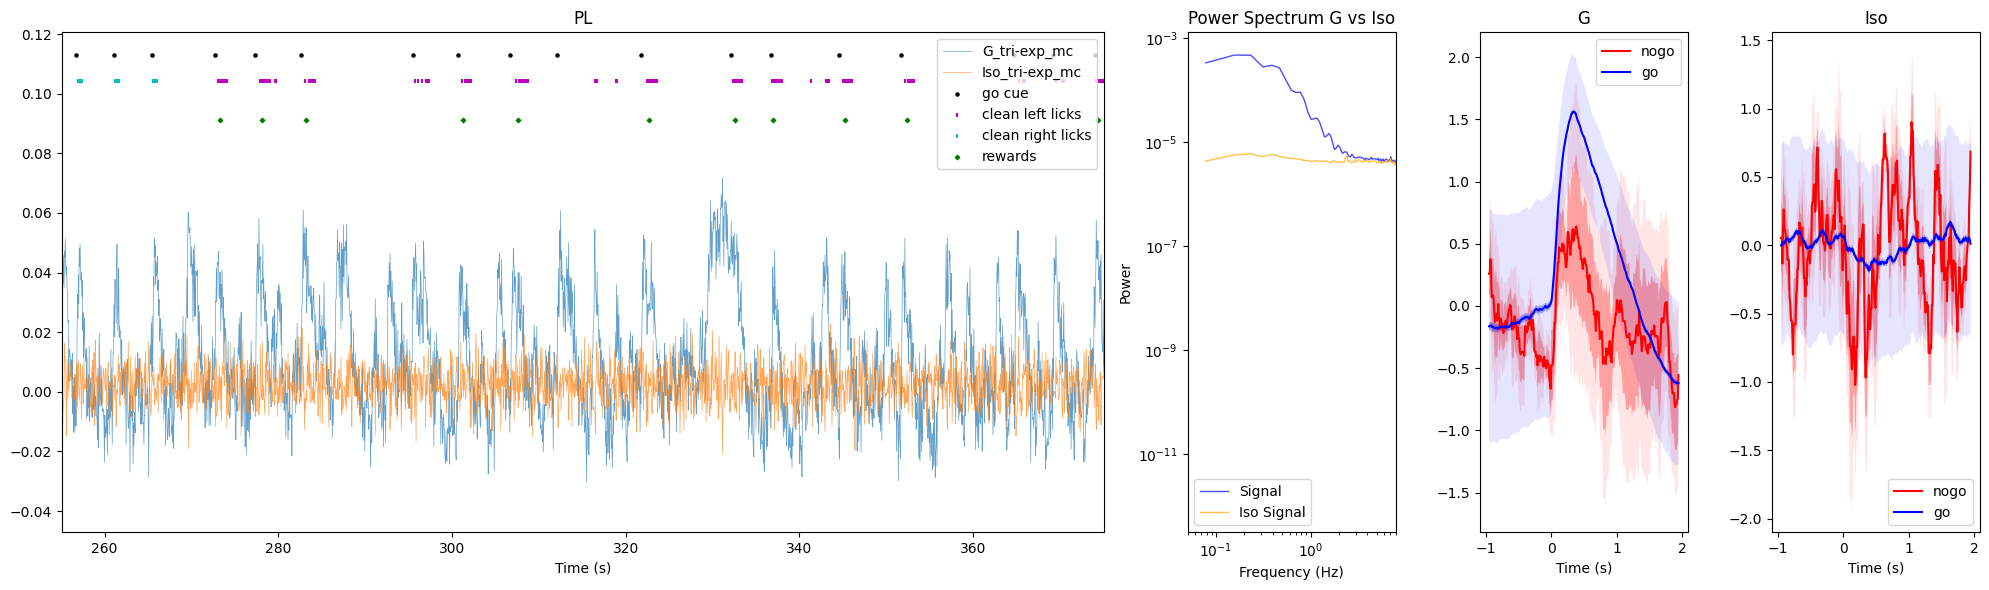

In [3]:
session = 'behavior_754896_2025-01-08_16-03-27'
fig = plot_G_vs_Iso(session, zscore_flag=False, raw_session=True)
##Figure5iright##
##FigureS17f##
##FigureS17e##
save_panels(fig, target_dir, 'example_session_trace', 'Figure5i_right', exts=("pdf",))
save_panels(fig, target_dir, 'example_licks', 'FigureS12e', exts=("pdf",))
save_panels(fig, target_dir, 'example_hit_vs_miss_G_vs_iso', 'FigureS17f', exts=("pdf",))
save_panels(fig, target_dir, 'power_spectrum', 'FigureS17e', exts=("pdf",))

In [4]:
# Extract data from plot_G_vs_Iso for CSV export (mirrors the function logic)
from scipy.signal import welch
_signal = get_FP_data(session, tar_channels=[('PL', 'G_tri-exp_mc'), ('PL', 'Iso_tri-exp_mc'), ('PL', 'G'), ('PL', 'Iso')])
_session_df = get_session_tbl(session, load_raw=True)
_fs = 20

region = 'PL'
# Figure5i_right: time-series trace (G and Iso, not z-scored to match zscore_flag=False)
trace_df = pd.DataFrame({
    'time': _signal['time_in_beh'],
    'G': _signal['G_tri-exp_mc'][region],
    'Iso': _signal['Iso_tri-exp_mc'][region],
})
save_panel_csv(trace_df, target_dir, f'example_session_trace_{region}', ['Figure5i_right'])

# FigureS12e
licks = load_licks(session)
licks_L = licks['licks_L_cleaned']
licks_R = licks['licks_R_cleaned']
cols = ['goCue_start_time', 'reward_outcome_time']

# Build tidy event DataFrame: one row per event, event_type + time + trial columns
_trial_events = _session_df[cols + [c for c in _session_df.columns if c not in cols]].copy()
_trial_events.insert(0, 'event_type', 'trial')
_trial_events.insert(1, 'time', _trial_events['goCue_start_time'])
_lick_L_df = pd.DataFrame({'event_type': 'lick_L', 'time': licks_L})
_lick_R_df = pd.DataFrame({'event_type': 'lick_R', 'time': licks_R})
combined_session_df = pd.concat([_trial_events, _lick_L_df, _lick_R_df], ignore_index=True, sort=False)
combined_session_df = combined_session_df.sort_values('time').reset_index(drop=True)

save_panel_csv(combined_session_df, target_dir, f'example_licks_{region}', ['FigureS12e'])

# FigureS17e: power spectrum
_sig_g = _signal['G'][region]; _sig_g = _sig_g[~np.isnan(_sig_g)]
_f_g, _Pxx_g = welch(_sig_g, fs=_fs, window='hann', nperseg=min(256, len(_sig_g)), detrend='constant', scaling='density')
_mask_g = (_f_g > 0) & (_f_g <= 8)
_sig_iso = _signal['Iso'][region]; _sig_iso = _sig_iso[~np.isnan(_sig_iso)]
_f_iso, _Pxx_iso = welch(_sig_iso, fs=_fs, window='hann', nperseg=min(256, len(_sig_iso)), detrend='constant', scaling='density')
_mask_iso = (_f_iso > 0) & (_f_iso <= 8)
psd_df = pd.DataFrame({
    'frequency': _f_g[_mask_g],
    'G_power': _Pxx_g[_mask_g],
    'Iso_power': _Pxx_iso[_mask_iso],
})
save_panel_csv(psd_df, target_dir, f'power_spectrum_{region}', ['FigureS17e'])

# FigureS17f: PSTH G and Iso aligned to go/nogo, with SE
_nogo_times = _session_df.loc[_session_df['animal_response']==2, 'goCue_start_time'].values
_go_times   = _session_df.loc[_session_df['animal_response']!=2, 'goCue_start_time'].values
_g_nogo_mat, _g_nogo_mean, _g_bins, _ = align_signal_to_events(zscore(_signal['G_tri-exp_mc'][region].copy()), _signal['time_in_beh'], _nogo_times)
_g_go_mat,   _g_go_mean,   _g_bins, _ = align_signal_to_events(zscore(_signal['G_tri-exp_mc'][region].copy()), _signal['time_in_beh'], _go_times)
_iso_nogo_mat, _iso_nogo_mean, _iso_bins, _ = align_signal_to_events(zscore(_signal['Iso_tri-exp_mc'][region].copy()), _signal['time_in_beh'], _nogo_times)
_iso_go_mat,   _iso_go_mean,   _iso_bins, _ = align_signal_to_events(zscore(_signal['Iso_tri-exp_mc'][region].copy()), _signal['time_in_beh'], _go_times)
_g_nogo_se   = np.nanstd(_g_nogo_mat,   axis=0) / np.sqrt(np.sum(~np.isnan(_g_nogo_mat),   axis=0))
_g_go_se     = np.nanstd(_g_go_mat,     axis=0) / np.sqrt(np.sum(~np.isnan(_g_go_mat),     axis=0))
_iso_nogo_se = np.nanstd(_iso_nogo_mat, axis=0) / np.sqrt(np.sum(~np.isnan(_iso_nogo_mat), axis=0))
_iso_go_se   = np.nanstd(_iso_go_mat,   axis=0) / np.sqrt(np.sum(~np.isnan(_iso_go_mat),   axis=0))
psth_df = pd.DataFrame({
    'time': _g_bins,
    'G_go_mean': _g_go_mean,
    'G_go_se': _g_go_se,
    'G_nogo_mean': _g_nogo_mean,
    'G_nogo_se': _g_nogo_se,
    'Iso_go_mean': _iso_go_mean,
    'Iso_go_se': _iso_go_se,
    'Iso_nogo_mean': _iso_nogo_mean,
    'Iso_nogo_se': _iso_nogo_se,
})
save_panel_csv(psth_df, target_dir, f'hit_vs_miss_G_vs_iso_{region}', ['FigureS17f'])

['/root/capsule/scratch/results/manuscript/figures/F_FP_examples/FigureS17f_hit_vs_miss_G_vs_iso_PL.csv']

In [5]:
# ##Figure5iright## Left most panel in fig
##FigureS17f## 2 Right most panel in fig
##FigureS17e## second panel on left in fig

In [6]:
example_session = 'behavior_754896_2025-01-07_14-08-54'
session_dir = session_dirs(example_session)
panels = ['FigureS17c', 'FigureS17d']

In [ ]:
example_session = 'behavior_754896_2025-01-07_14-08-54'
session_dir = session_dirs(example_session)
panels = ['FigureS17c', 'FigureS17d']

In [8]:
# make csv
G_raw = f'{session_dir['raw_dir']}/fib/FIP_DataG_2025-01-07T14_08_54.csv'
G_raw_df = pd.read_csv(G_raw, header=None)
iso_raw = f'{session_dir['raw_dir']}/fib/FIP_DataIso_2025-01-07T14_08_54.csv'
iso_raw_df = pd.read_csv(iso_raw)
tar_list = [('PL', 'G_tri-exp-mc'), 
        ('PL', 'G_tri-exp'), 
        ('PL', 'iso_tri-exp-mc'),
        ('PL', 'iso_tri-exp'),
        ('PL', 'G'),
        ('PL', 'Iso'),
        ]
signal = get_FP_data(example_session, tar_channels=tar_list)

Channel G: region PL recorded at fiber 0
Channel G: region TH recorded at fiber 1
Channel G: region Gi recorded at fiber 2
Channel Iso: region PL recorded at fiber 0
Channel Iso: region TH recorded at fiber 1
Channel Iso: region Gi recorded at fiber 2


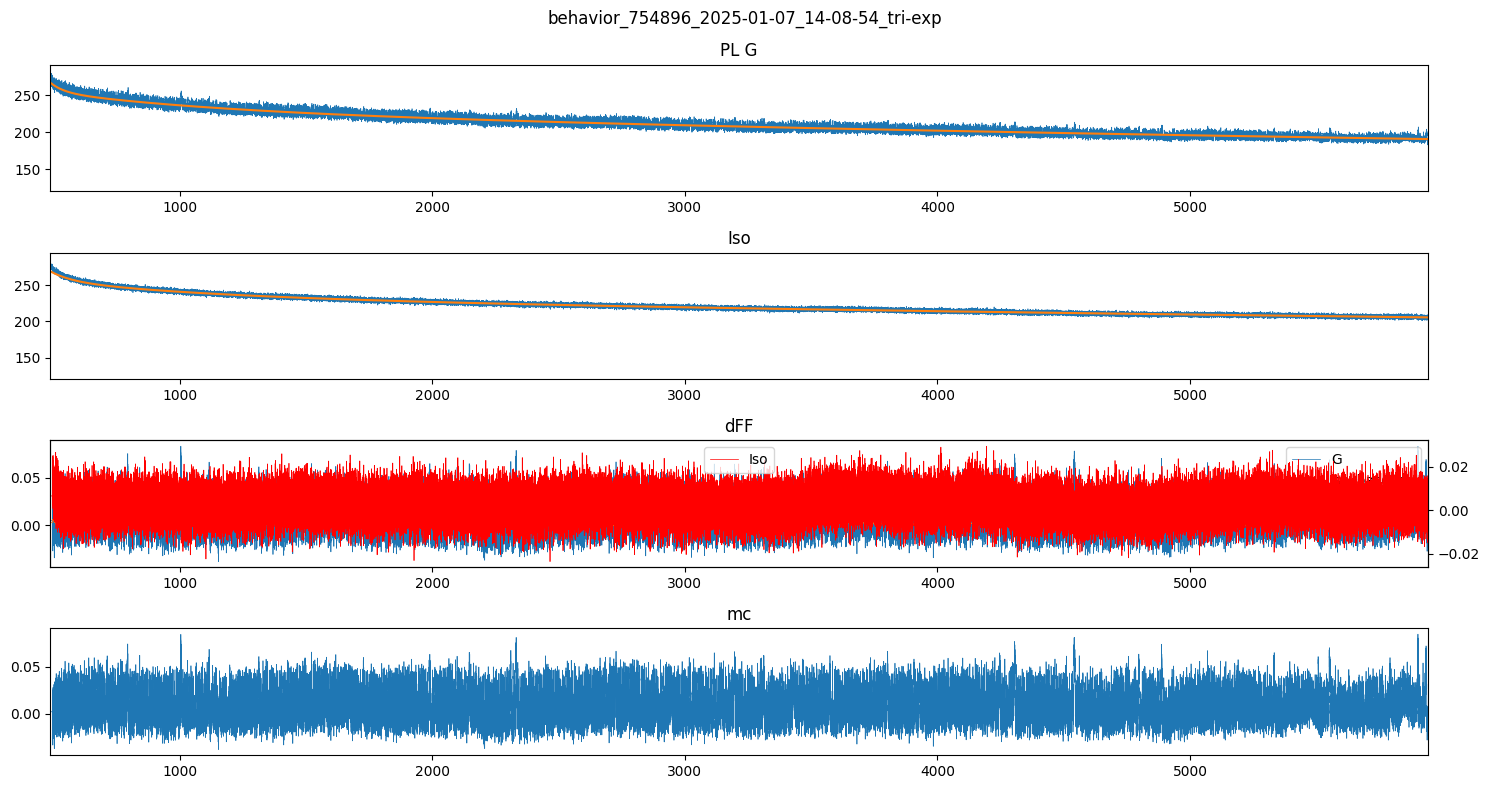

Saved CSV rows: 109129, columns: ['time', 'PL_G_raw', 'PL_Iso_raw', 'PL_G_tri-exp_baseline_fit', 'PL_Iso_tri-exp_baseline_fit', 'PL_G_tri-exp', 'PL_Iso_tri-exp', 'PL_G_tri-exp_mc', 'PL_G_tri-exp_iso_baseline']


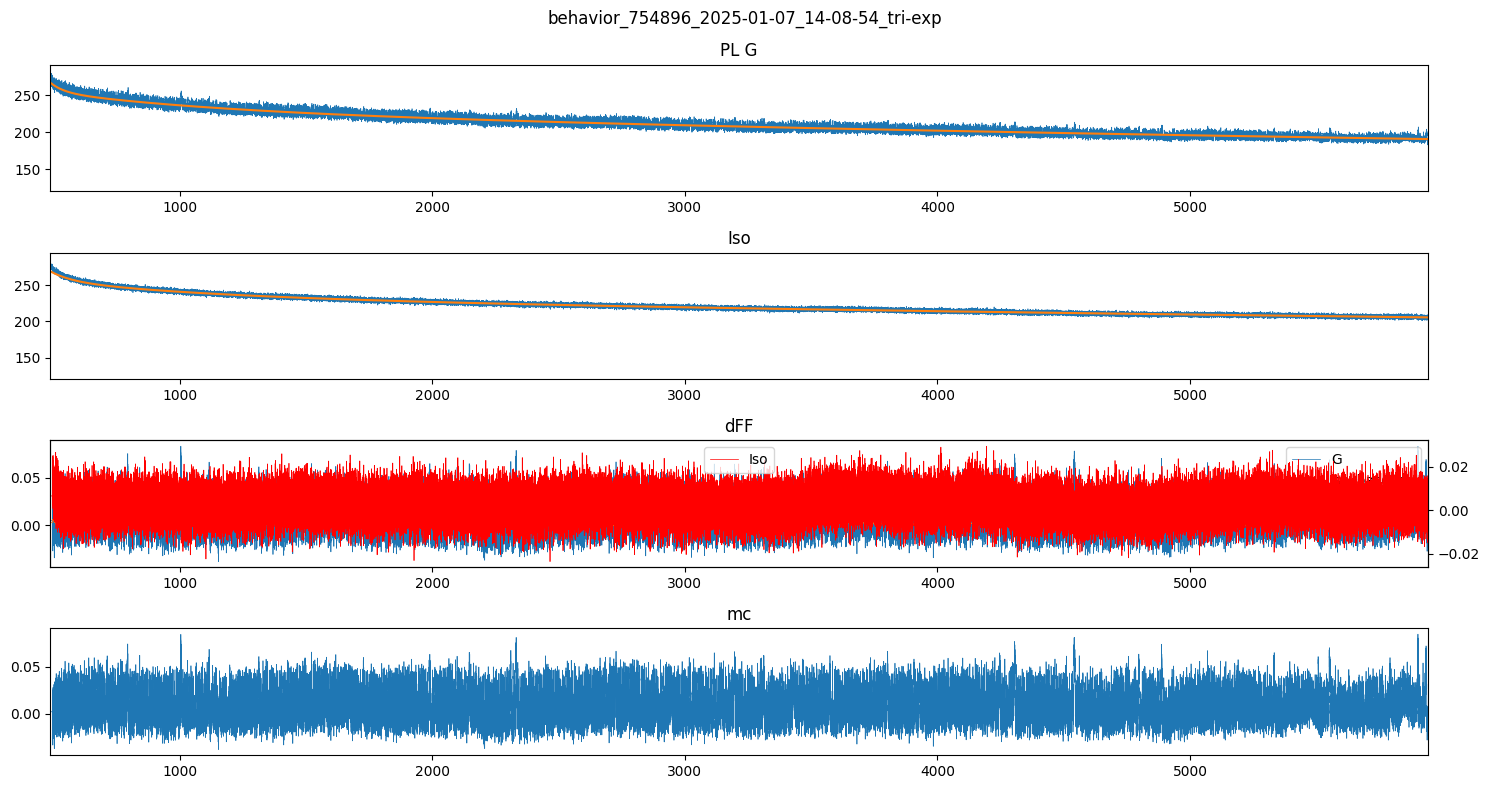

In [9]:
# Test plot_FP_preprocessing with the RAW signal + fitted-baseline params overlaid on rows 0/1
# (matches the upstream usage in aind_su_etal_2022_conversion
# notebooks/photometry_analysis_prep_motion.ipynb § "plot preprocessing").
from utils.photometry_utils import (
    plot_FP_preprocessing,
    load_session_FP_raw,
    load_session_FP_params,
    double_exp,
    triple_exp,
    bright,
)

_signal_prep = get_FP_data(example_session, tar_channels=None)
_signal_raw = load_session_FP_raw(example_session, channels=('G', 'Iso'), plot=False)
_params = load_session_FP_params(example_session)
assert _params is not None, 'combined_params.pkl not found for this session'

_region = 'PL'
_methods = ('tri-exp',)

_figs = plot_FP_preprocessing(
    example_session,
    signal_region_prep=_signal_prep,
    params=_params,
    signal_region_raw=_signal_raw,
    regions=_region,
    methods=_methods,
    save=False,
)
for _f in _figs:
    display(_f)

# --- CSV export: every trace + timestamp shown in the figure ---
_baseline_fns = {'exp': double_exp, 'bright': bright, 'tri-exp': triple_exp}
_time = np.asarray(_signal_prep['time_in_beh'])

# Raw traces (overlay dict — same trick plot_FP_preprocessing uses internally)
_raw_G = np.asarray(_signal_raw['G'][_region])
_raw_Iso = np.asarray(_signal_raw['Iso'][_region])
_n = min(len(_time), len(_raw_G), len(_raw_Iso))
_cols = {'time': _time[:_n], f'{_region}_G_raw': _raw_G[:_n], f'{_region}_Iso_raw': _raw_Iso[:_n]}

for _method in _methods:
    _base_fn = _baseline_fns[_method]
    _p_G = _params.get(f'G_{_method}', {}).get(_region)
    _p_Iso = _params.get(f'Iso_{_method}', {}).get(_region)
    _cols[f'{_region}_G_{_method}_baseline_fit'] = (
        _base_fn(_n, np.asarray(_p_G)) if _p_G is not None and len(_p_G) > 0
        else np.full(_n, np.nan)
    )
    _cols[f'{_region}_Iso_{_method}_baseline_fit'] = (
        _base_fn(_n, np.asarray(_p_Iso)) if _p_Iso is not None and len(_p_Iso) > 0
        else np.full(_n, np.nan)
    )
    _g_pp = np.asarray(_signal_prep[f'G_{_method}'][_region])[:_n]
    _g_mc = np.asarray(_signal_prep[f'G_{_method}_mc'][_region])[:_n]
    _iso_pp = np.asarray(_signal_prep[f'Iso_{_method}'][_region])[:_n]
    _cols[f'{_region}_G_{_method}'] = _g_pp
    _cols[f'{_region}_Iso_{_method}'] = _iso_pp
    _cols[f'{_region}_G_{_method}_mc'] = _g_mc
    _cols[f'{_region}_G_{_method}_iso_baseline'] = _g_pp - _g_mc

_df = pd.DataFrame(_cols)
_name = f'FP_preprocessing_{example_session}_{_region}_{"_".join(_methods)}'
save_panel_csv(_df, target_dir, _name, panels)
print(f'Saved CSV rows: {len(_df)}, columns: {list(_df.columns)}')

# Example psth

In [3]:
example = [('behavior_749472_2025-01-08_13-43-07', 'FigureS17h_left'),
           ('behavior_754898_2025-01-06_17-49-54', 'FigureS17j')]

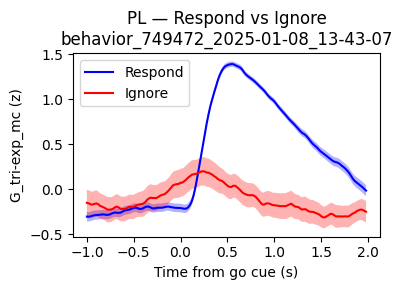

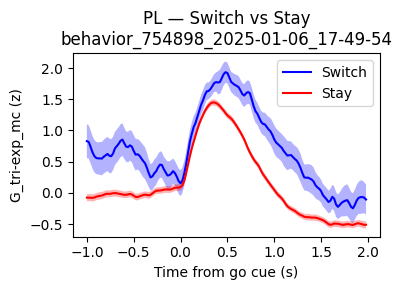

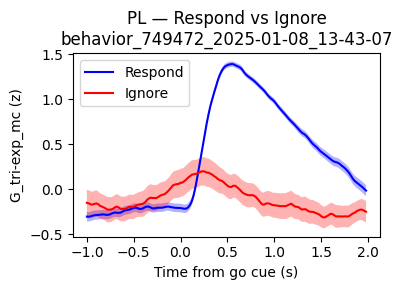

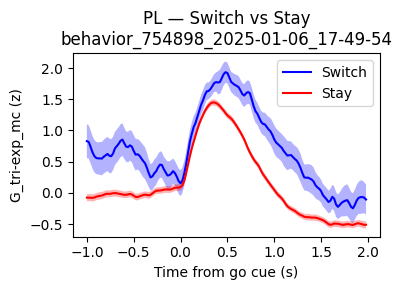

In [9]:
# FigureS17h_left  : Respond vs Ignore, aligned to go cue (behavior_749472_2025-01-08_13-43-07)
# FigureS17j       : Switch vs Stay,   aligned to go cue (behavior_754898_2025-01-06_17-49-54)
# Uses the same loading path as plot_G_vs_Iso: get_FP_data + get_session_tbl.

_specs = [
    ('behavior_749472_2025-01-08_13-43-07', 'FigureS17h_left', 'respond_vs_ignore'),
    ('behavior_754898_2025-01-06_17-49-54', 'FigureS17j',      'switch_vs_stay'),
]
_channel = 'G_tri-exp_mc'
_region = 'PL'
_align_kwargs = dict(
    kernel=True, tau=0.15,
    pre_event_time=1, post_event_time=2,
    window_size=0.1, step_size=0.02,
)


def _split_masks(session_df, contrast):
    """Return (times, mask_a, mask_b, label_a, label_b, xlabel)."""
    goCue = session_df['goCue_start_time'].values
    response_mask = session_df['animal_response'].values != 2
    if contrast == 'respond_vs_ignore':
        return (goCue, response_mask, ~response_mask,
                'Respond', 'Ignore', 'Time from go cue (s)')
    if contrast == 'switch_vs_stay':
        # only on choice trials
        choices = session_df.loc[response_mask, 'animal_response'].values
        gc = session_df.loc[response_mask, 'goCue_start_time'].values
        switch = np.zeros(len(choices), dtype=bool)
        switch[1:] = choices[1:] != choices[:-1]
        return (gc, switch, ~switch,
                'Switch', 'Stay', 'Time from go cue (s)')
    raise ValueError(contrast)


for _session, _panel, _contrast in _specs:
    _signal = get_FP_data(_session, tar_channels=[(_region, _channel)])
    _session_df = get_session_tbl(_session)
    _sig = zscore(_signal[_channel][_region])
    _t = np.asarray(_signal['time_in_beh'])
    _times, _mA, _mB, _lblA, _lblB, _xlbl = _split_masks(_session_df, _contrast)

    fig, ax = plt.subplots(figsize=(4, 3))
    _matA, _meanA, _bins, _ = align_signal_to_events(
        _sig, _t, _times[_mA], ax=ax, color='b', legend=_lblA, plot_error=False, **_align_kwargs)
    _matB, _meanB, _binsB, _ = align_signal_to_events(
        _sig, _t, _times[_mB], ax=ax, color='r', legend=_lblB, plot_error=False, **_align_kwargs)
    ax.set_xlabel(_xlbl)
    ax.set_ylabel(f'{_channel} (z)')
    ax.set_title(f'{_region} — {_lblA} vs {_lblB}\n{_session}')
    ax.legend()
    plt.tight_layout()

    _name = f'FP_{_contrast}_{_session}_{_region}_{_channel}'
    save_panels(fig, target_dir, _name, [_panel], exts=('pdf',))

    _semA = np.nanstd(_matA, axis=0) / np.sqrt(np.sum(~np.isnan(_matA), axis=0))
    _semB = np.nanstd(_matB, axis=0) / np.sqrt(np.sum(~np.isnan(_matB), axis=0))
    save_panel_csv(
        columns_to_df(
            time_s=_bins,
            **{f'{_lblA}_mean': _meanA, f'{_lblA}_sem': _semA,
               f'{_lblB}_mean': _meanB, f'{_lblB}_sem': _semB},
        ),
        target_dir, _name, [_panel],
    )
    display(fig)
    # plt.close(fig)
##FigureS17h_left##
##FigureS17j##